<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

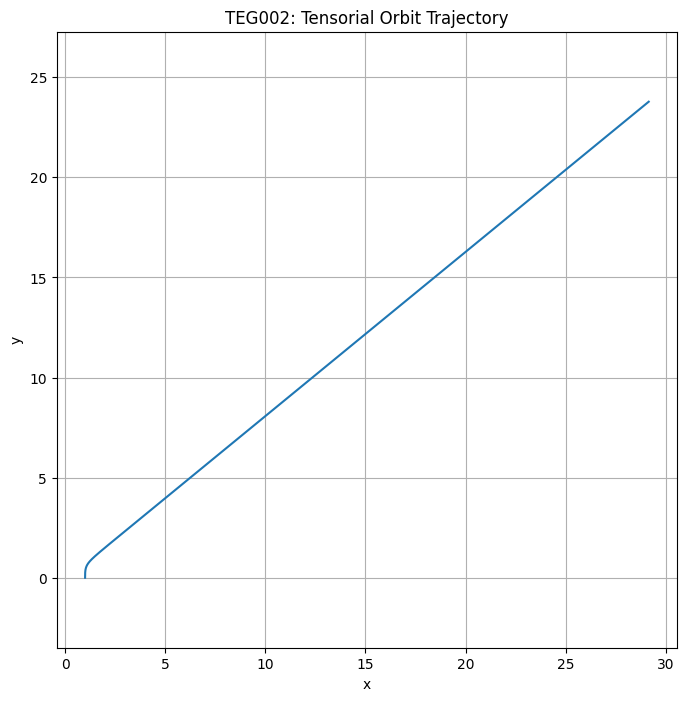

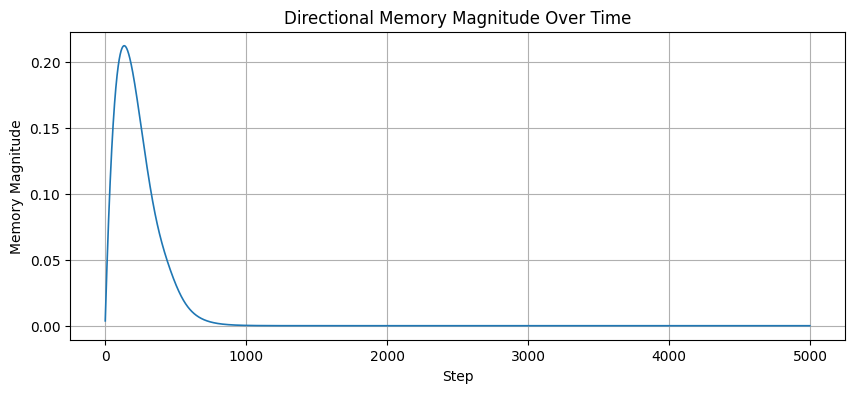

Drift Vector: [28.14957044 -1.22537038]
Drift Magnitude: 28.176228427691335


In [1]:
# 🧬 TEG002: Drift & Memory Diagnostics
# Extends tensorial orbit simulation with directional memory and drift detection
# Author: Chris & Copilot | Arc VIII: Tensorial Emergence

import numpy as np
import matplotlib.pyplot as plt

# 📐 Curvature Tensor Module
def curvature_tensor(x, y, sigma=1.0):
    exp_term = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Cxx = (1 - x**2 / sigma**2) * exp_term
    Cyy = (1 - y**2 / sigma**2) * exp_term
    Cxy = (-x * y / sigma**2) * exp_term
    return np.array([[Cxx, Cxy], [Cxy, Cyy]])

# 🧲 Tensor-Contraction Force
def tensor_force(x, y, vx, vy, sigma=1.0):
    C = curvature_tensor(x, y, sigma)
    v = np.array([vx, vy])
    f = -np.dot(C, v)
    return f[0], f[1]

# 🔁 Velocity Update Rule (Entropic)
def update_velocity(vx, vy, fx, fy, dt):
    return vx + fx * dt, vy + fy * dt

# 🧠 Directional Memory Coupling
def update_memory_field(x, y, vx, vy, prev_memory, alpha=0.01):
    grad_x = (1 - x**2) * np.exp(-x**2 - y**2)
    grad_y = (1 - y**2) * np.exp(-x**2 - y**2)
    curvature_gradient = np.array([grad_x, grad_y])
    memory_update = alpha * curvature_gradient + 0.99 * prev_memory
    return memory_update

# 🚀 Simulation Loop with Memory
def simulate_tensorial_orbit(x0, y0, vx0, vy0, steps=10000, dt=0.01, sigma=1.0):
    x, y = x0, y0
    vx, vy = vx0, vy0
    trajectory = []
    memory_field = []

    prev_memory = np.array([0.0, 0.0])

    for _ in range(steps):
        fx, fy = tensor_force(x, y, vx, vy, sigma)
        vx, vy = update_velocity(vx, vy, fx, fy, dt)
        x += vx * dt
        y += vy * dt
        trajectory.append((x, y))
        prev_memory = update_memory_field(x, y, vx, vy, prev_memory)
        memory_field.append(prev_memory.copy())

    return np.array(trajectory), np.array(memory_field)

# 📊 Trajectory Plot
def plot_trajectory(trajectory):
    x_vals, y_vals = trajectory[:,0], trajectory[:,1]
    plt.figure(figsize=(8, 8))
    plt.plot(x_vals, y_vals, linewidth=1.5)
    plt.title("TEG002: Tensorial Orbit Trajectory")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# 📊 Memory Field Plot (Magnitude)
def plot_memory_magnitude(memory_field):
    magnitudes = np.linalg.norm(memory_field, axis=1)
    plt.figure(figsize=(10, 4))
    plt.plot(magnitudes, linewidth=1.2)
    plt.title("Directional Memory Magnitude Over Time")
    plt.xlabel("Step")
    plt.ylabel("Memory Magnitude")
    plt.grid(True)
    plt.show()

# 🧭 Drift Detection
def detect_drift(trajectory, initial_velocity, dt):
    final_displacement = trajectory[-1] - trajectory[0]
    expected_displacement = np.array(initial_velocity) * dt * len(trajectory)
    drift_vector = final_displacement - expected_displacement
    drift_magnitude = np.linalg.norm(drift_vector)
    return drift_vector, drift_magnitude

# 🧪 Run Simulation
x0, y0 = 1.0, 0.0
vx0, vy0 = 0.0, 0.5
steps = 5000
dt = 0.01
sigma = 1.0

trajectory, memory_field = simulate_tensorial_orbit(x0, y0, vx0, vy0, steps, dt, sigma)
plot_trajectory(trajectory)
plot_memory_magnitude(memory_field)

drift_vector, drift_magnitude = detect_drift(trajectory, (vx0, vy0), dt)
print("Drift Vector:", drift_vector)
print("Drift Magnitude:", drift_magnitude)
